# Lib


In [ ]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Section 1
Compare Dice Coefficient using :
1. Binary Thresholding with a fixed threshold.
2. Otsu's Method.
3. Optimized thresholding using the Dice Coefficient.
4.
Visualize the results by comparison of the original image, ground truth mask, and the results from each thresholding method.

P.S: Use skimage library

Input Image

In [ ]:
!gdown "1sWYKuwLg_1nFylJ1h9Xpjr5zy-1-BwcN"  # Input image

Downloading...
From: https://drive.google.com/uc?id=1sWYKuwLg_1nFylJ1h9Xpjr5zy-1-BwcN
To: /content/LAB05 IMG1.png
100% 61.6k/61.6k [00:00<00:00, 76.7MB/s]


Ground Truth Image


In [ ]:
!gdown "15jipoft8qFVghFrLVlWTDJmvtZTKuVeB" # Ground Truth

Downloading...
From: https://drive.google.com/uc?id=15jipoft8qFVghFrLVlWTDJmvtZTKuVeB
To: /content/LAB05 IMG2.png
100% 15.4k/15.4k [00:00<00:00, 31.1MB/s]


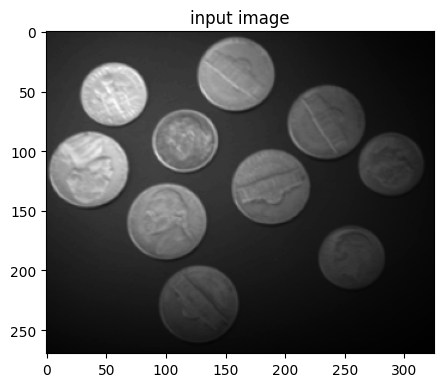

In [ ]:
# Load and display the input image
# Answer your code here
image_1 = '/content/LAB05 IMG1.png'
image_input = io.imread(image_1, as_gray=True)  # Load as grayscale
image_input = (image_input * 255).astype(np.uint8)
plt.figure(figsize=(5, 5))
plt.title('input image')
plt.imshow(image_input, cmap='gray')

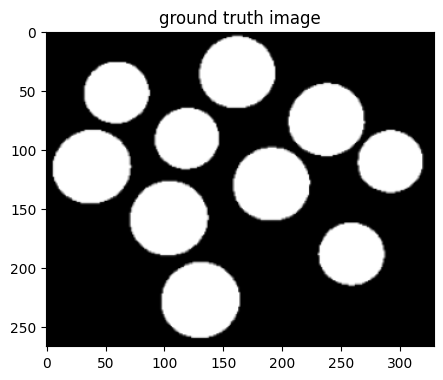

In [ ]:
# Load and display the ground truth image
# Answer your code here
image_2 = '/content/LAB05 IMG2.png'
image_G = io.imread(image_2, as_gray=True)  # Load as grayscale
image_G = (image_G * 255).astype(np.uint8)
plt.figure(figsize=(5, 5))
plt.title('ground truth image')
plt.imshow(image_G, cmap='gray')

## Answer



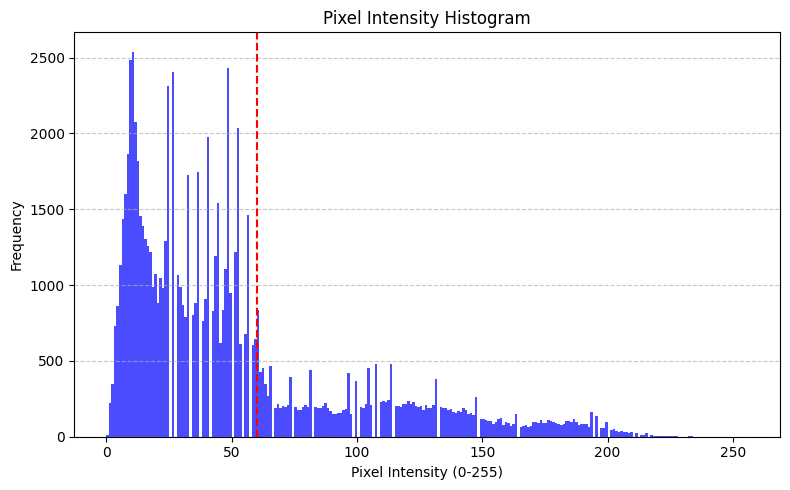

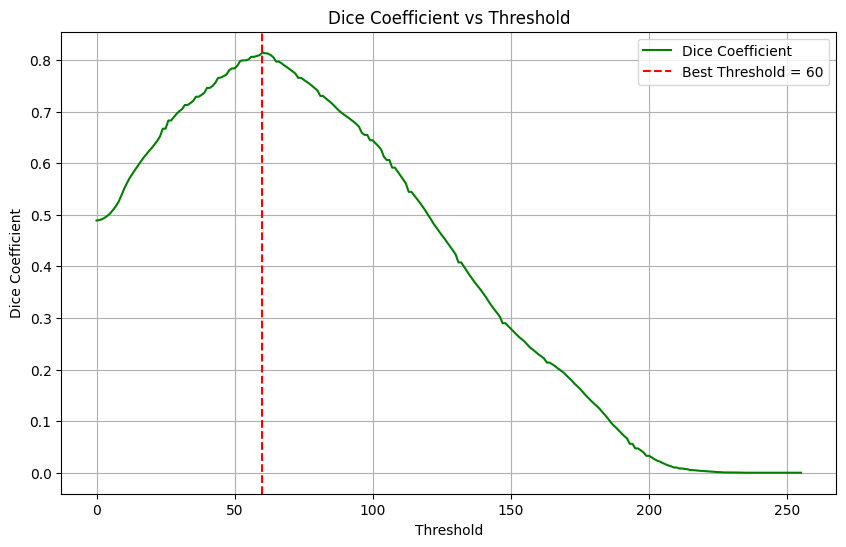

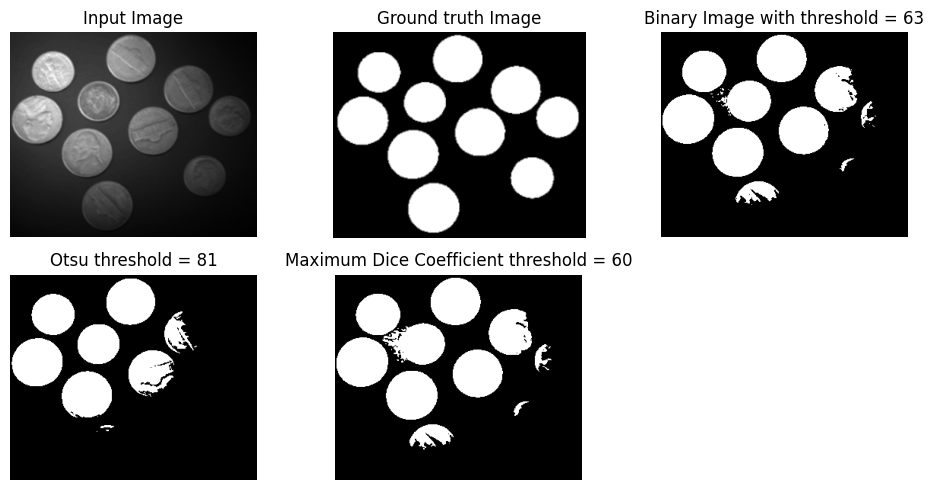

In [ ]:
from skimage.filters import threshold_otsu
from skimage.transform import resize

# Answer your code here
# grayscale [0 - 255] ; black -> white

# Set the threshold value
# tested : 65 70 75
threshold_value = 63

# Perform binarization
binary_image = np.where(image_input >= threshold_value, 255, 0).astype(np.uint8)

# Calculate the threshold using Otsu's method
otsu_threshold = threshold_otsu(image_input)

# Apply thresholding
otsu_image = image_input > otsu_threshold

# Load ground truth and resize it to match input image size
image_G_resized = resize(image_G, (image_input.shape),anti_aliasing = False)

# print(image_G_resized.shape)
# print(image_input.shape)

best_threshold = 0
max_dice = 0
dice_values = []  # Store Dice coefficient for each threshold

for threshold in range(256):
    binary_image_ = (image_input > threshold).astype(np.uint8)  # Binary segmentation (0 or 1)

    # Calculate Dice coefficient
    intersection = np.sum(binary_image_ * image_G_resized)
    dice_coefficient = (2. * intersection) / (np.sum(binary_image_) + np.sum(image_G_resized) + 1e-6)
    dice_values.append(dice_coefficient)  # Store Dice coefficient

    # Update best threshold if current Dice coefficient is greater
    if dice_coefficient > max_dice:
        max_dice = dice_coefficient
        best_threshold = threshold

plt.figure(figsize=(8, 5))
plt.hist(image_input.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7) # ravel flattens a multi-dimensional array  into a 1D array. This is necessary because histograms are computed based on a 1D array of values, where each value corresponds to a pixel intensity.
plt.title('Pixel Intensity Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')

#plot threshold
plt.axvline(x=60, color='r', linestyle='--', linewidth=1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines for easier readability
plt.tight_layout()
plt.show()

# Visualize the results
plt.figure(figsize=(10, 6))

# Plot Dice coefficient as a function of threshold
plt.plot(range(256), dice_values, label="Dice Coefficient", color="green")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best Threshold = {best_threshold}")
plt.title("Dice Coefficient vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid()
plt.show()

# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.title("Input Image")
plt.imshow(image_input, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Ground truth Image')
plt.imshow(image_G, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title(f'Binary Image with threshold = {threshold_value}')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title(f'Otsu threshold = {otsu_threshold}')
plt.imshow(otsu_image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title(f'Maximum Dice Coefficient threshold = {best_threshold}')
binary_image_best = (image_input > best_threshold).astype(np.uint8)
plt.imshow(binary_image_best, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


# Section 2
Image Clustering
1. Use the given image and try clustering with 3 different k.
2. Compare and display the results.
3. In which scenario, small k or large k, do the dogs in the image retain the most visual detail?

P.S: Use OpenCV library

In [ ]:
!gdown "1VwgQxqmhhZTCRqI77kkS6cVRunBzZdsa" # Input image for clustering

Downloading...
From: https://drive.google.com/uc?id=1VwgQxqmhhZTCRqI77kkS6cVRunBzZdsa
To: /content/LAB 05 shiba.jpg
100% 99.2k/99.2k [00:00<00:00, 90.2MB/s]


### Answer

In [ ]:
from sklearn.cluster import KMeans

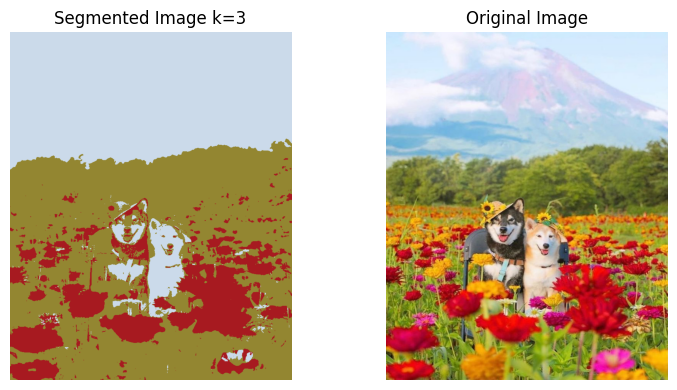

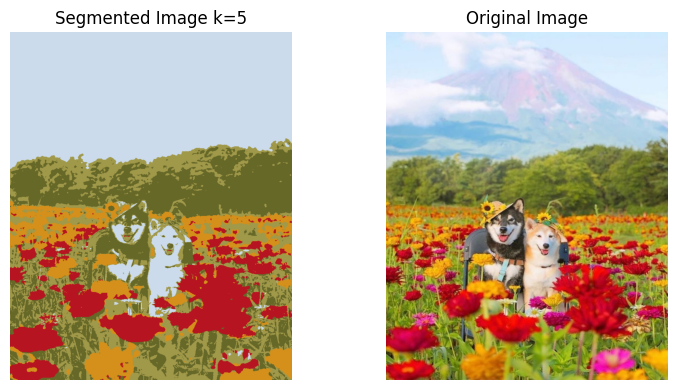

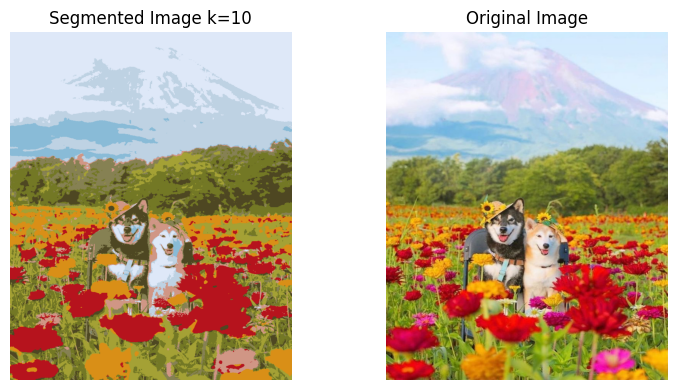

In [ ]:
# Answer your code here
shiba_rgb = cv2.cvtColor(cv2.imread('/content/LAB 05 shiba.jpg'),cv2.COLOR_BGR2RGB)
pixels = shiba_rgb.reshape(-1,3)
k = [3, 5, 10]

for i in k:
  kmeans = KMeans(n_clusters=i, random_state=0).fit(pixels)
  segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
  segmented_image = segmented_pixels.reshape(shiba_rgb.shape).astype('uint8')

  plt.figure(figsize=(8, 4))
  plt.subplot(1, 2, 1)
  plt.title(f"Segmented Image k={i}")
  plt.imshow(segmented_image)
  plt.axis("off")

  plt.subplot(1, 2, 2)
  plt.title(f"Original Image")
  plt.imshow(shiba_rgb)
  plt.axis("off")

  plt.tight_layout()
  plt.show()

### Segment by Elbow cluster

<ipython-input-5-db46c2da07b9>:11: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(k_values, inertia, 'o-', label='Inertia', marker='o')


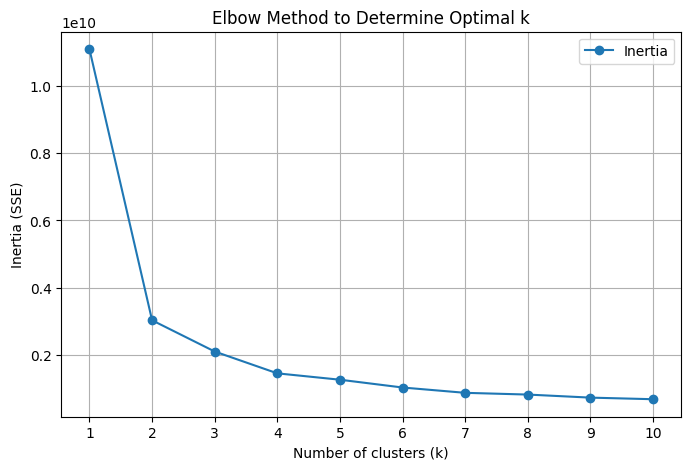

In [ ]:
# Initialize a list to store inertia values
inertia = [] # compactness
k_values = range(1, 11)  # Range of cluster numbers from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(pixels) # Fit the KMeans model on the pixel
    inertia.append(kmeans.inertia_)  # save Inertia

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'o-', label='Inertia', marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()


(-0.5, 735.5, 909.5, -0.5)

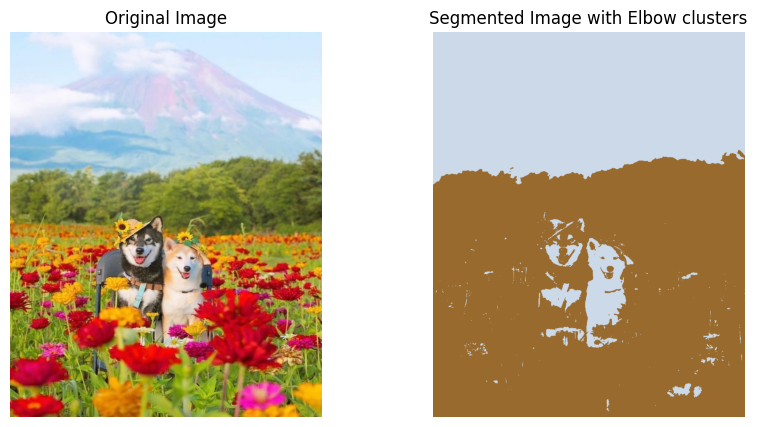

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_pixels.reshape(shiba_rgb.shape).astype('uint8')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(shiba_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title('Segmented Image with Elbow clusters')
plt.imshow(segmented_image)
plt.axis("off")

# Section 3

Binary image processing (Basic operators)


> Data that you'll use in this section is "old text paragraph image" and implement to solve each prblem to get result with scikit-image libraries.


1.   In image there has some alphabets which missing and faded so you need to make whole paragraph more clear and easy to read than original image.



In [ ]:
#import data
!gdown 11WNV3Yr6hZNpRVF4ftNaNF8DYyVlWJlX

Downloading...
From: https://drive.google.com/uc?id=11WNV3Yr6hZNpRVF4ftNaNF8DYyVlWJlX
To: /content/OldText.png
100% 148k/148k [00:00<00:00, 7.35MB/s]


In [ ]:
from skimage import morphology

(-0.5, 784.5, 477.5, -0.5)

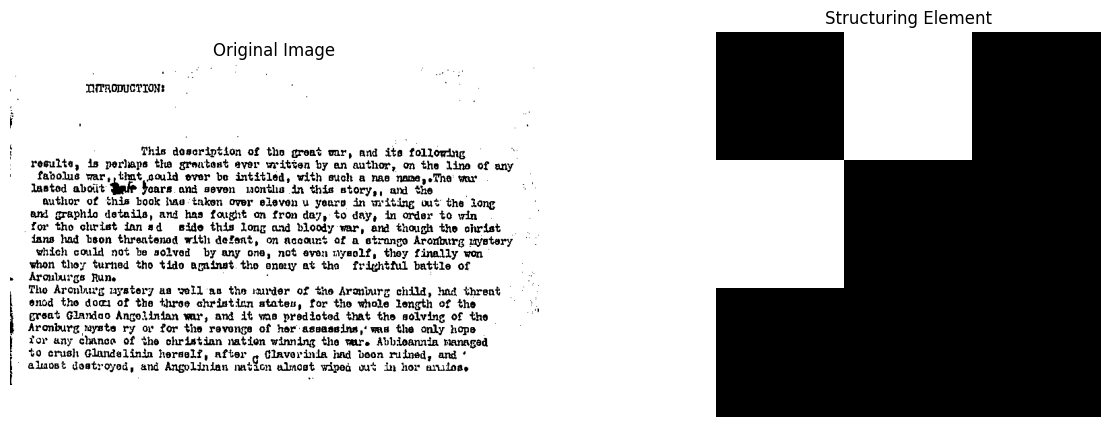

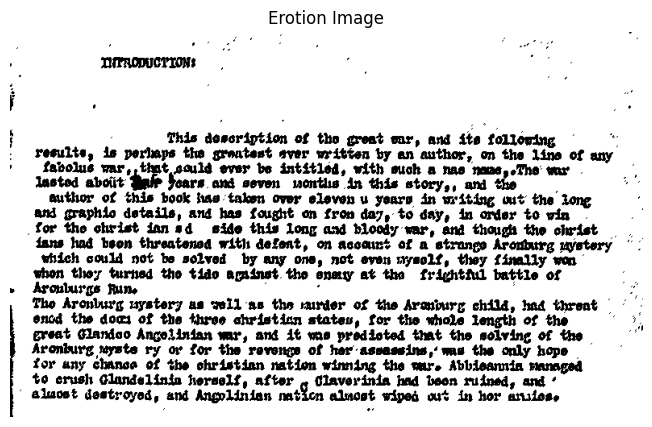

In [ ]:
old_image = '/content/OldText.png'
image_old = io.imread(old_image, as_gray=True)  # Load as grayscale
binary_image_old = np.where(image_old >= 0.5, 1, 0).astype(np.uint8)

structuring_element = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 0],
], dtype=np.uint8)

erotion_image = morphology.erosion(binary_image_old, structuring_element)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(binary_image_old, cmap='gray', vmin=0, vmax=1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title('Structuring Element')
plt.imshow(structuring_element, cmap='gray', vmin=0, vmax=1)
plt.axis("off")

plt.figure(figsize=(10, 5))
plt.title('Erotion Image')
plt.imshow(erotion_image, cmap='gray', vmin=0, vmax=1)
plt.axis("off")


2. If you can see background of text image is having some noise. To make our background clear you need to remove noises as much as possible.

(-0.5, 784.5, 477.5, -0.5)

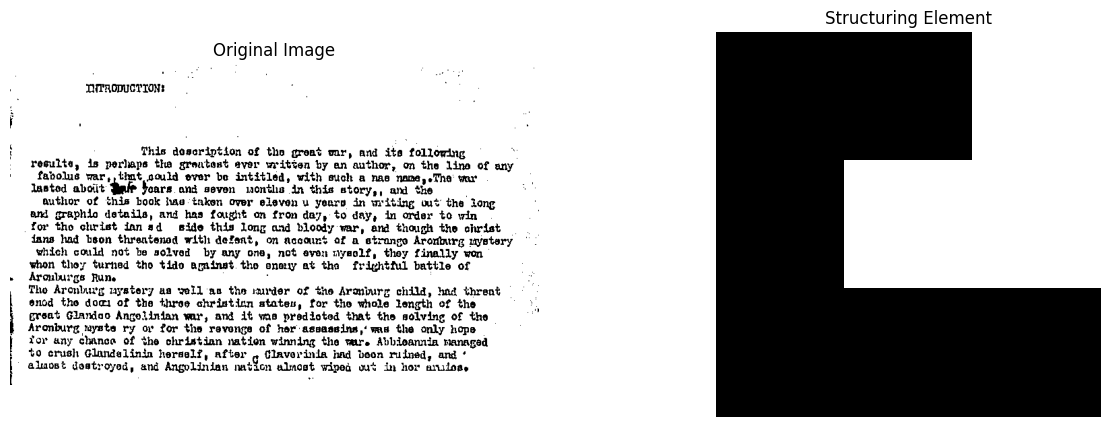

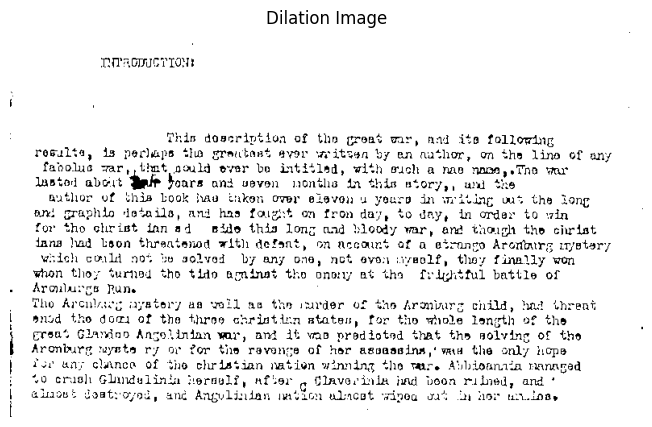

In [ ]:
# Answer your code here
old_image = '/content/OldText.png'
image_old = io.imread(old_image, as_gray=True)  # Load as grayscale
binary_image_old = np.where(image_old >= 0.5, 1, 0).astype(np.uint8)

structuring_element = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [0, 0, 0],
], dtype=np.uint8)

erotion_image = morphology.dilation(binary_image_old, structuring_element)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(binary_image_old, cmap='gray', vmin=0, vmax=1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title('Structuring Element')
plt.imshow(structuring_element, cmap='gray', vmin=0, vmax=1)
plt.axis("off")

plt.figure(figsize=(10, 5))
plt.title('Dilation Image')
plt.imshow(erotion_image, cmap='gray', vmin=0, vmax=1)
plt.axis("off")


# Section 4

Binary image processing (Measurement)


> Data that you'll use in this section is "Mitosis cells" and implement to solve each prblem to get result with scikit-image libraries.


1.   Please show this following details of


*   Show area of objects.
*   Create bounding box cover each objects.
*   Show centroid of each objects.
*   Show eccentricity of each objects.
*   Show solidity of each objects.





Downloading...
From: https://drive.google.com/uc?id=1_mCcNuUPuSPUew0T-EmoTZBRNcOJ0jDM
To: /content/mitosis_mod.tif
100% 5.16k/5.16k [00:00<00:00, 19.0MB/s]


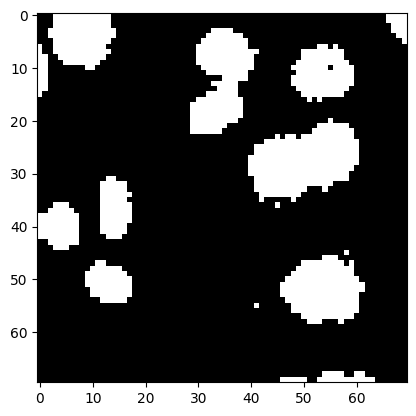

In [ ]:
#import data
!gdown 1_mCcNuUPuSPUew0T-EmoTZBRNcOJ0jDM

image_path = '/content/mitosis_mod.tif'
image_cells = io.imread(image_path, as_gray=True)
image_cells_binary = image_cells > 65
plt.imshow(image_cells_binary,cmap='gray')

In [ ]:
from skimage.segmentation import mark_boundaries
from skimage.measure import label, regionprops, find_contours

## Answer 1 (Show area of objects)

Largest area is  =  221.0


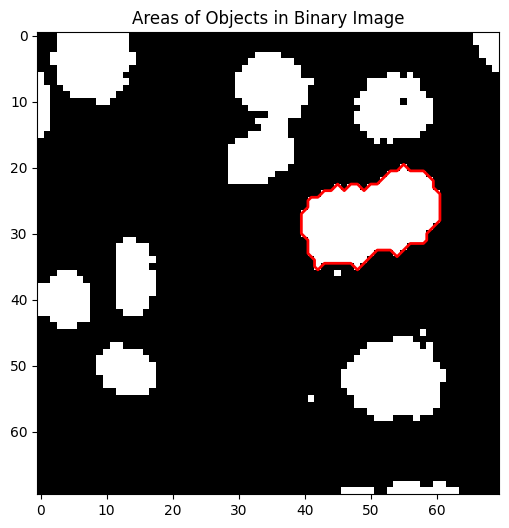

In [ ]:
# Answer your code here

labeled_image = label(image_cells_binary, connectivity=2)

regions = regionprops(labeled_image)

largest_region = max(regions, key=lambda region: region.area)

largest_region_mask = np.zeros_like(labeled_image, dtype=bool)
largest_region_mask[labeled_image == largest_region.label] = True

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.contour(largest_region_mask, colors='red', linewidths=2)
ax.set_title('Areas of Objects in Binary Image')

print("Largest area is  = ",largest_region.area)

## Answer 2 (Create bounding box cover each objects)

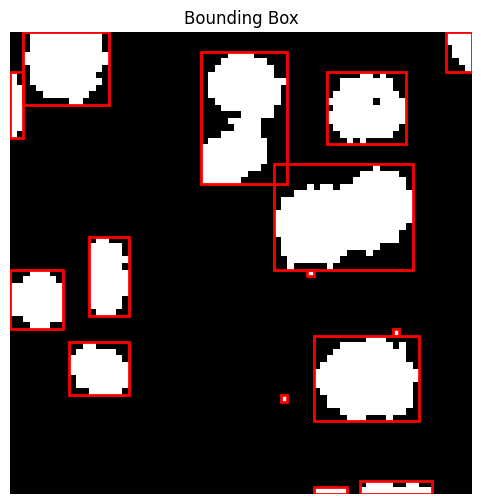

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray')
ax.set_title('Bounding Box')

for region in regions:
    min_row, min_col, max_row, max_col = region.bbox

    rect = plt.Rectangle(
        (min_col-0.5, min_row-0.5),
        max_col - min_col,
        max_row - min_row,
        edgecolor='red',
        facecolor='none',
        linewidth=2
    )
    ax.add_patch(rect)

plt.axis('off')
plt.show()

## Answer 3 (Show centroid of each objects)

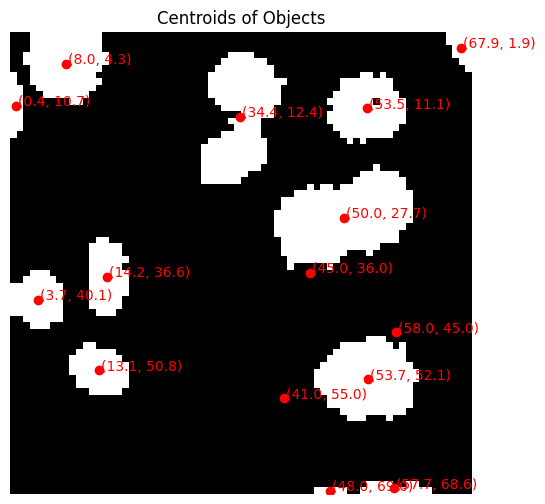

In [ ]:
from skimage.measure import centroid

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Centroids of Objects')

for region in regions:
    centroid_y, centroid_x = region.centroid

    ax.plot(centroid_x, centroid_y,'ro')  # 'ro' means red circle
    ax.text(centroid_x+0.3 , centroid_y, f'({centroid_x:.1f}, {centroid_y:.1f})',
            color='red', fontsize=10)

plt.axis('off')
plt.show()

## Answer 4 (Show eccentricity of each objects)

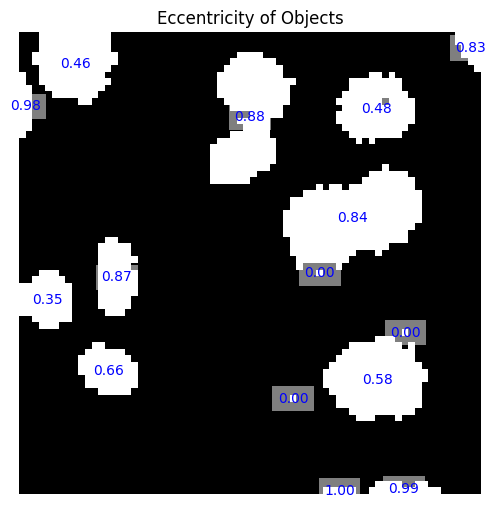

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Eccentricity of Objects')

for region in regions:
    centroid_y, centroid_x = region.centroid
    eccentricity = region.eccentricity

    ax.text(
        centroid_x, centroid_y, f'{eccentricity:.2f}',
        color='blue', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.5)
    )

plt.axis('off')
plt.show()


## Answer 5 (Show solidity of each objects)

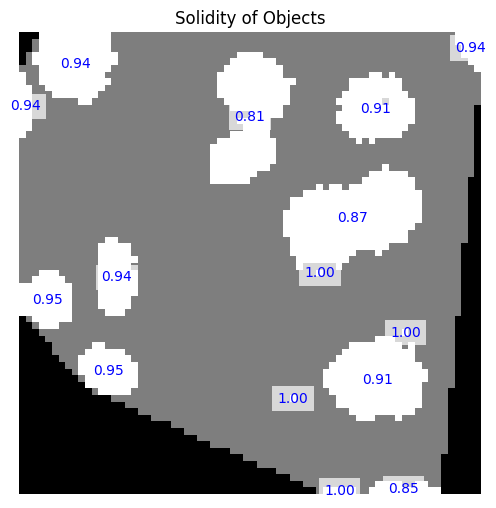

Solidity is =  1.0


In [ ]:
from skimage.morphology import convex_hull_image

convex_hull = convex_hull_image(image_cells_binary)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_cells_binary, cmap='gray', interpolation='none')
ax.set_title('Solidity of Objects')

for region in regions:
    centroid_y, centroid_x = region.centroid
    solidity = region.solidity

    ax.text(
        centroid_x, centroid_y, f'{solidity:.2f}',
        color='blue', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

ax.imshow(convex_hull, cmap='gray', interpolation='none', alpha=0.5)
plt.axis('off')
plt.show()

print("Solidity is = ",solidity)